# [LAB 07] 추론 통계 - 1. 추론통계 개요

## #01. 준비작업 

### 1. 패키지 설치 

In [59]:
!pip install --upgrade scipy


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조 

In [60]:
from jussam import load_data
from helpers import *
from math import sqrt       # 루트 처리 함수
from scipy.stats import t   # t분포 객체 

### 3. 데이터 가져오기 

In [61]:
origin = load_data('height')
origin.head()

📚 어느 학교의 학년, 성별, 키에 대한 가상의 조사 자료 (출처: 방송통신대학교 통계학개론)


,학년,성별,키
0,1,남자,163
1,2,여자,154
2,1,남자,171
3,3,여자,160
4,4,남자,169


## #02. 신뢰구간 구하기 

### 1. 신뢰구간을 계산할 데이터 

In [62]:
data = origin['키']
data.head()

0    163
1    154
2    171
3    160
4    169
Name: 키, dtype: int64

### 2. 신뢰수준 정의 

In [63]:
clevel = 0.95

### 3. 샘플 사이즈 

In [64]:
n = len(data)
n

36

### 4. 자유도 

In [65]:
dof = n-1
dof 

35

### 5. 표본평균 

In [66]:
sample_mean = data.mean()
sample_mean

np.float64(167.83333333333334)

### 6. 표본표준편차 

In [67]:
sample_std = data.std()
sample_std

np.float64(7.315345905306578)

### 7. 표본표준오차 

In [68]:
sample_std_error = sample_std / sqrt(n)
sample_std_error 

np.float64(1.2192243175510964)

### 8. 신뢰구간 

In [69]:
cmin, cmax = t.interval(clevel, dof, loc=sample_mean, 
                        scale=sample_std_error)
cmin, cmax

(np.float64(165.35817637995726), np.float64(170.30849028670943))

## #03. 모듈 기능 확인 

### 1. 연속형 데이터를 전달하는 형식 

In [70]:
my_stats.ci(data, clevel=0.95)

(np.float64(165.35817637995726), np.float64(170.30849028670943))

### 2. 데이터 프레임과 컬럼 이름을 지정하는 형식 

In [71]:
my_stats.ci(origin, column='키', clevel=0.95)

(np.float64(165.35817637995726), np.float64(170.30849028670943))

## #04. 신뢰구간 범위 시각화 

### 1. 신뢰구간 직접 시각화하기 

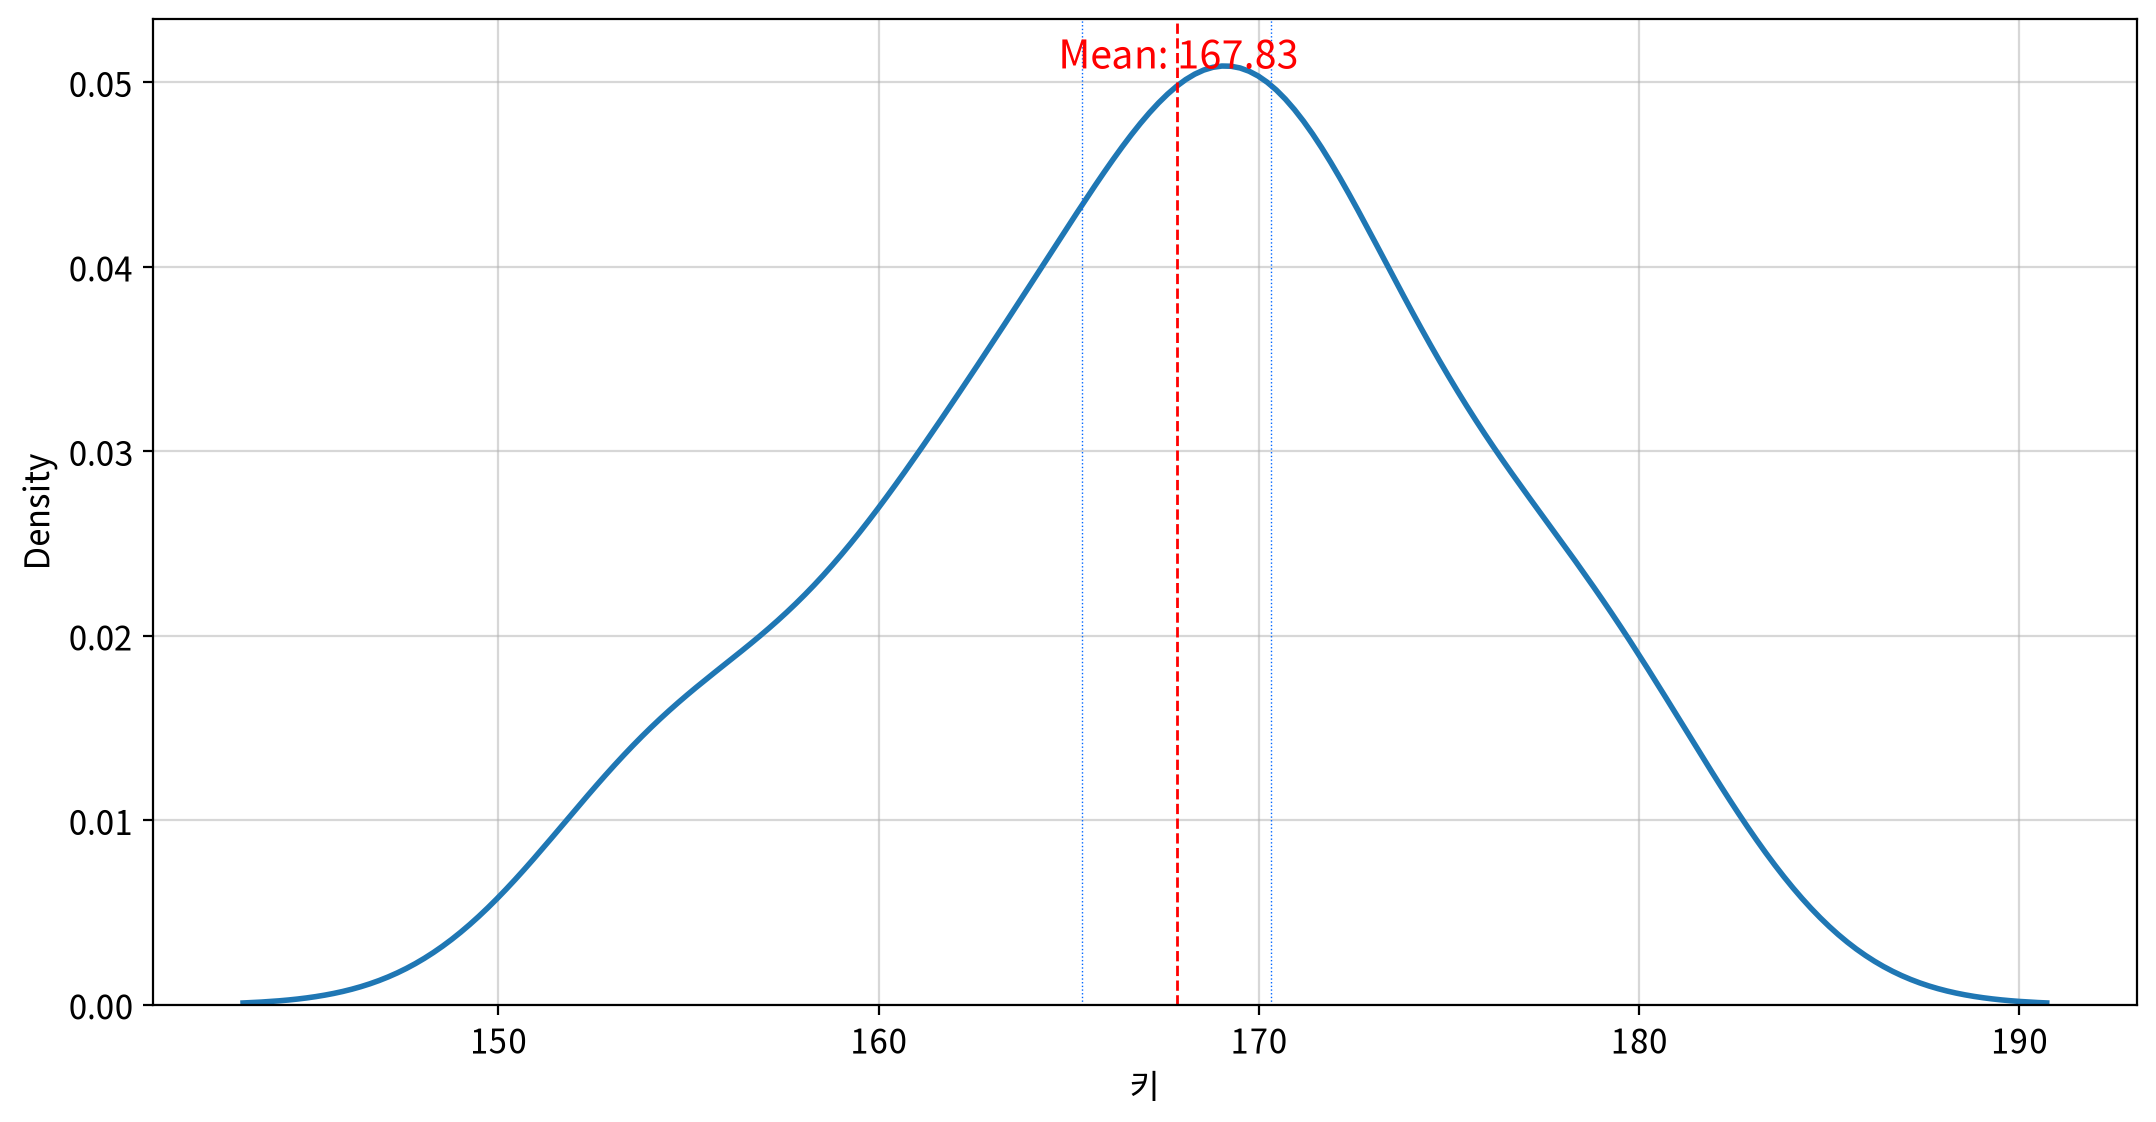

In [72]:
# ax 객체를 사용하여 추가적인 그래프 요소를 그릴 수 있도록 직접 초기화 
fig, ax = my_plot.init()

# KDE 플롯 그리기 (평균성 포함)
my_plot.kdeplot(origin, '키', meanline=True, ax=ax)

# 신뢰구간 계산 
cmin, cmax = my_stats.ci(origin, column='키', clevel=0.95)

# 신뢰구간 범위에 대한 세로 직선 그리기 (cmin ~ cmax) 
ax.axvline(cmin, linestyle=':', color='#0066ff', linewidth=0.5)
ax.axvline(cmax, linestyle=':', color='#0066ff', linewidth=0.5)


## #05. 시각화 모듈 기능 확인 

### 1. 단일 데이터에 대한 신뢰구간 확인 

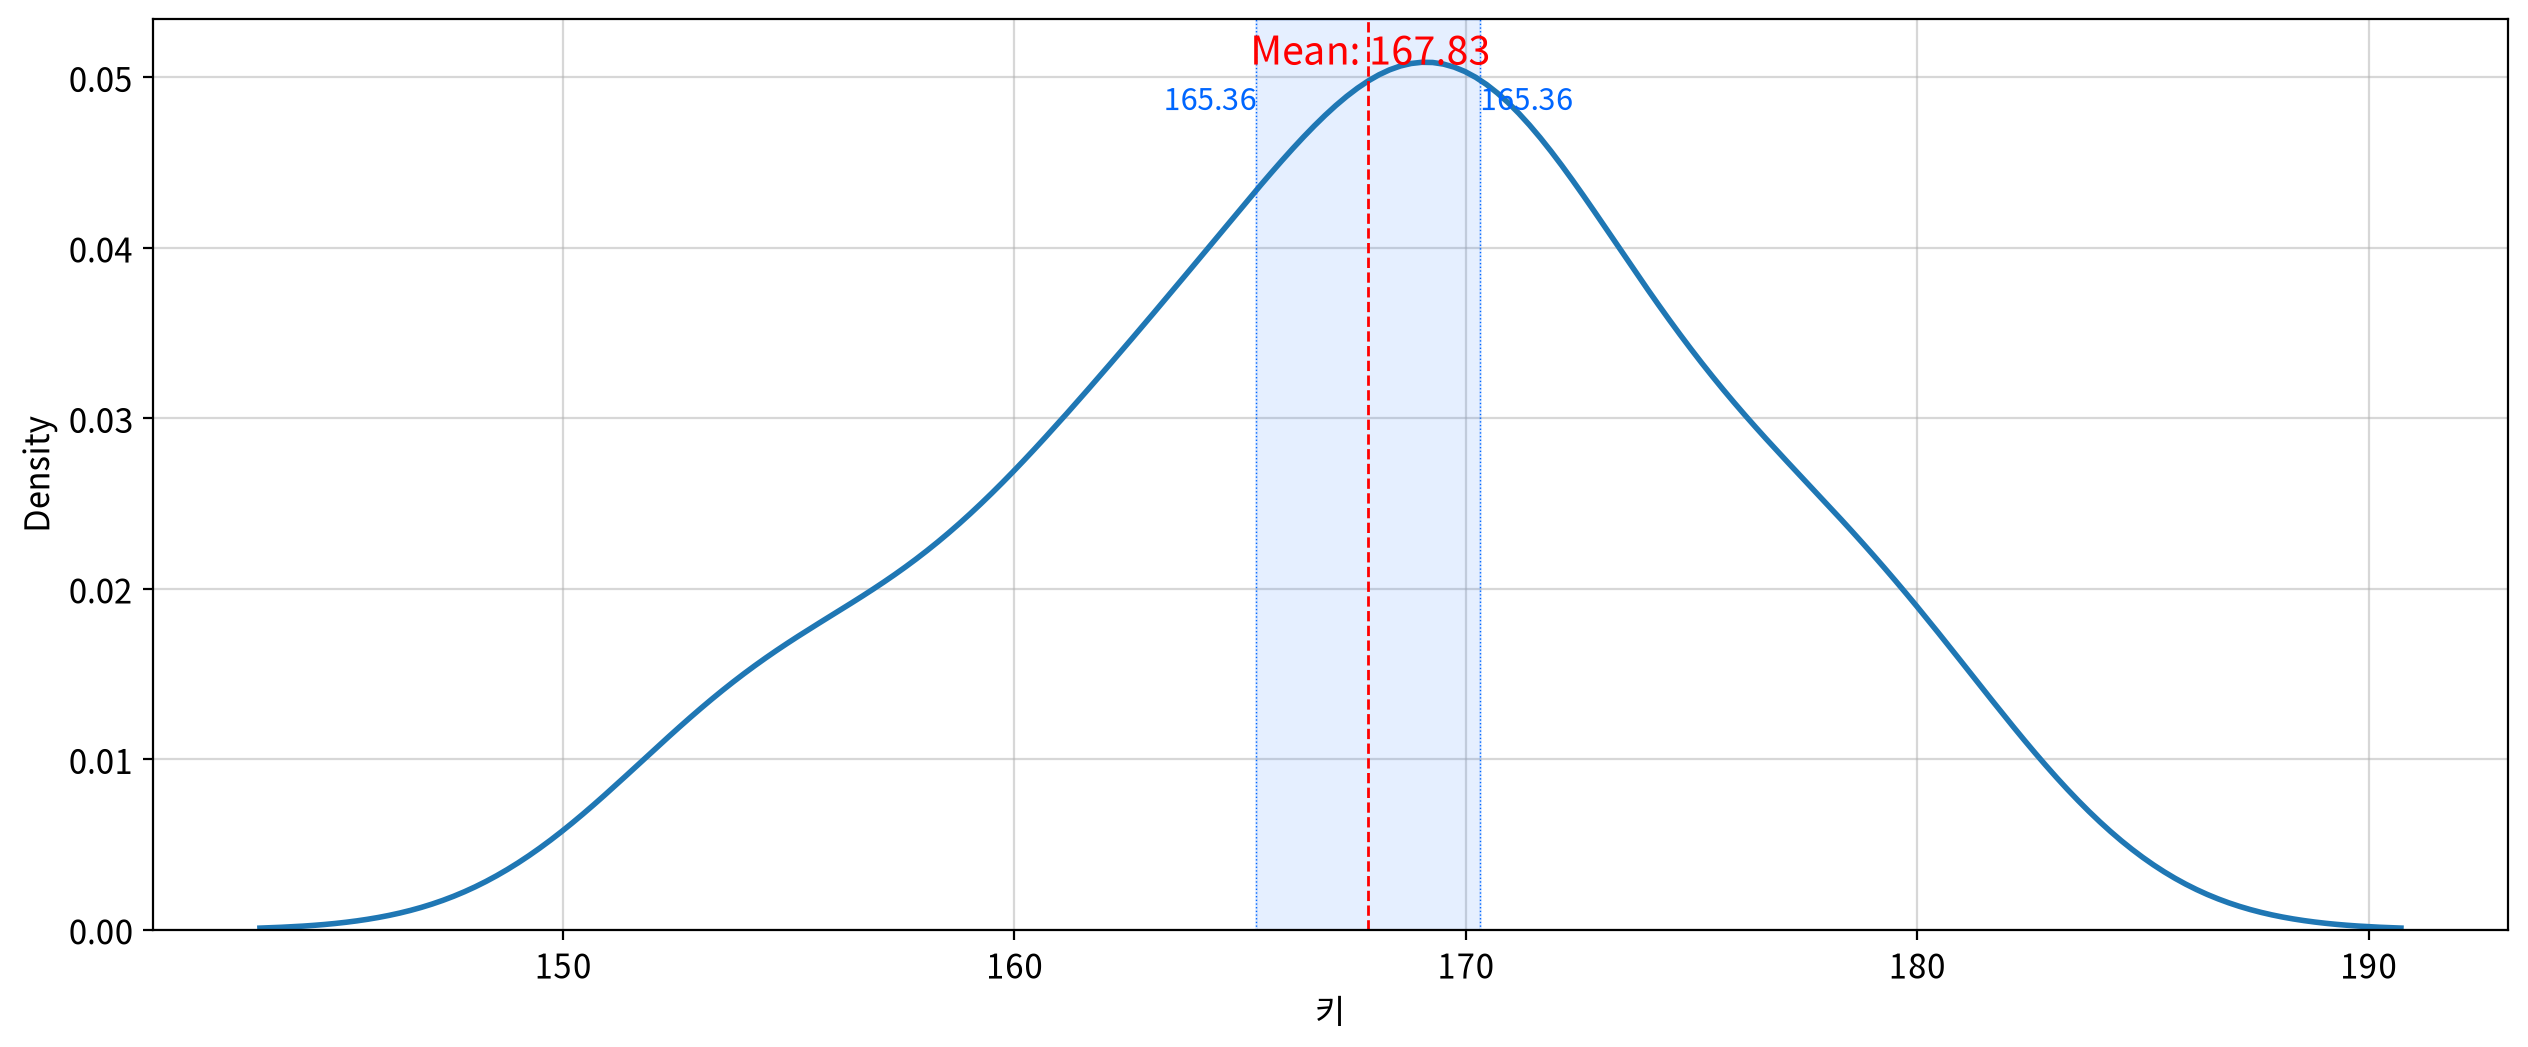

In [73]:
my_plot.kdeplot(origin, '키', meanline=True, clevel=0.95)

### 2. 범주별 신뢰구간 확인 

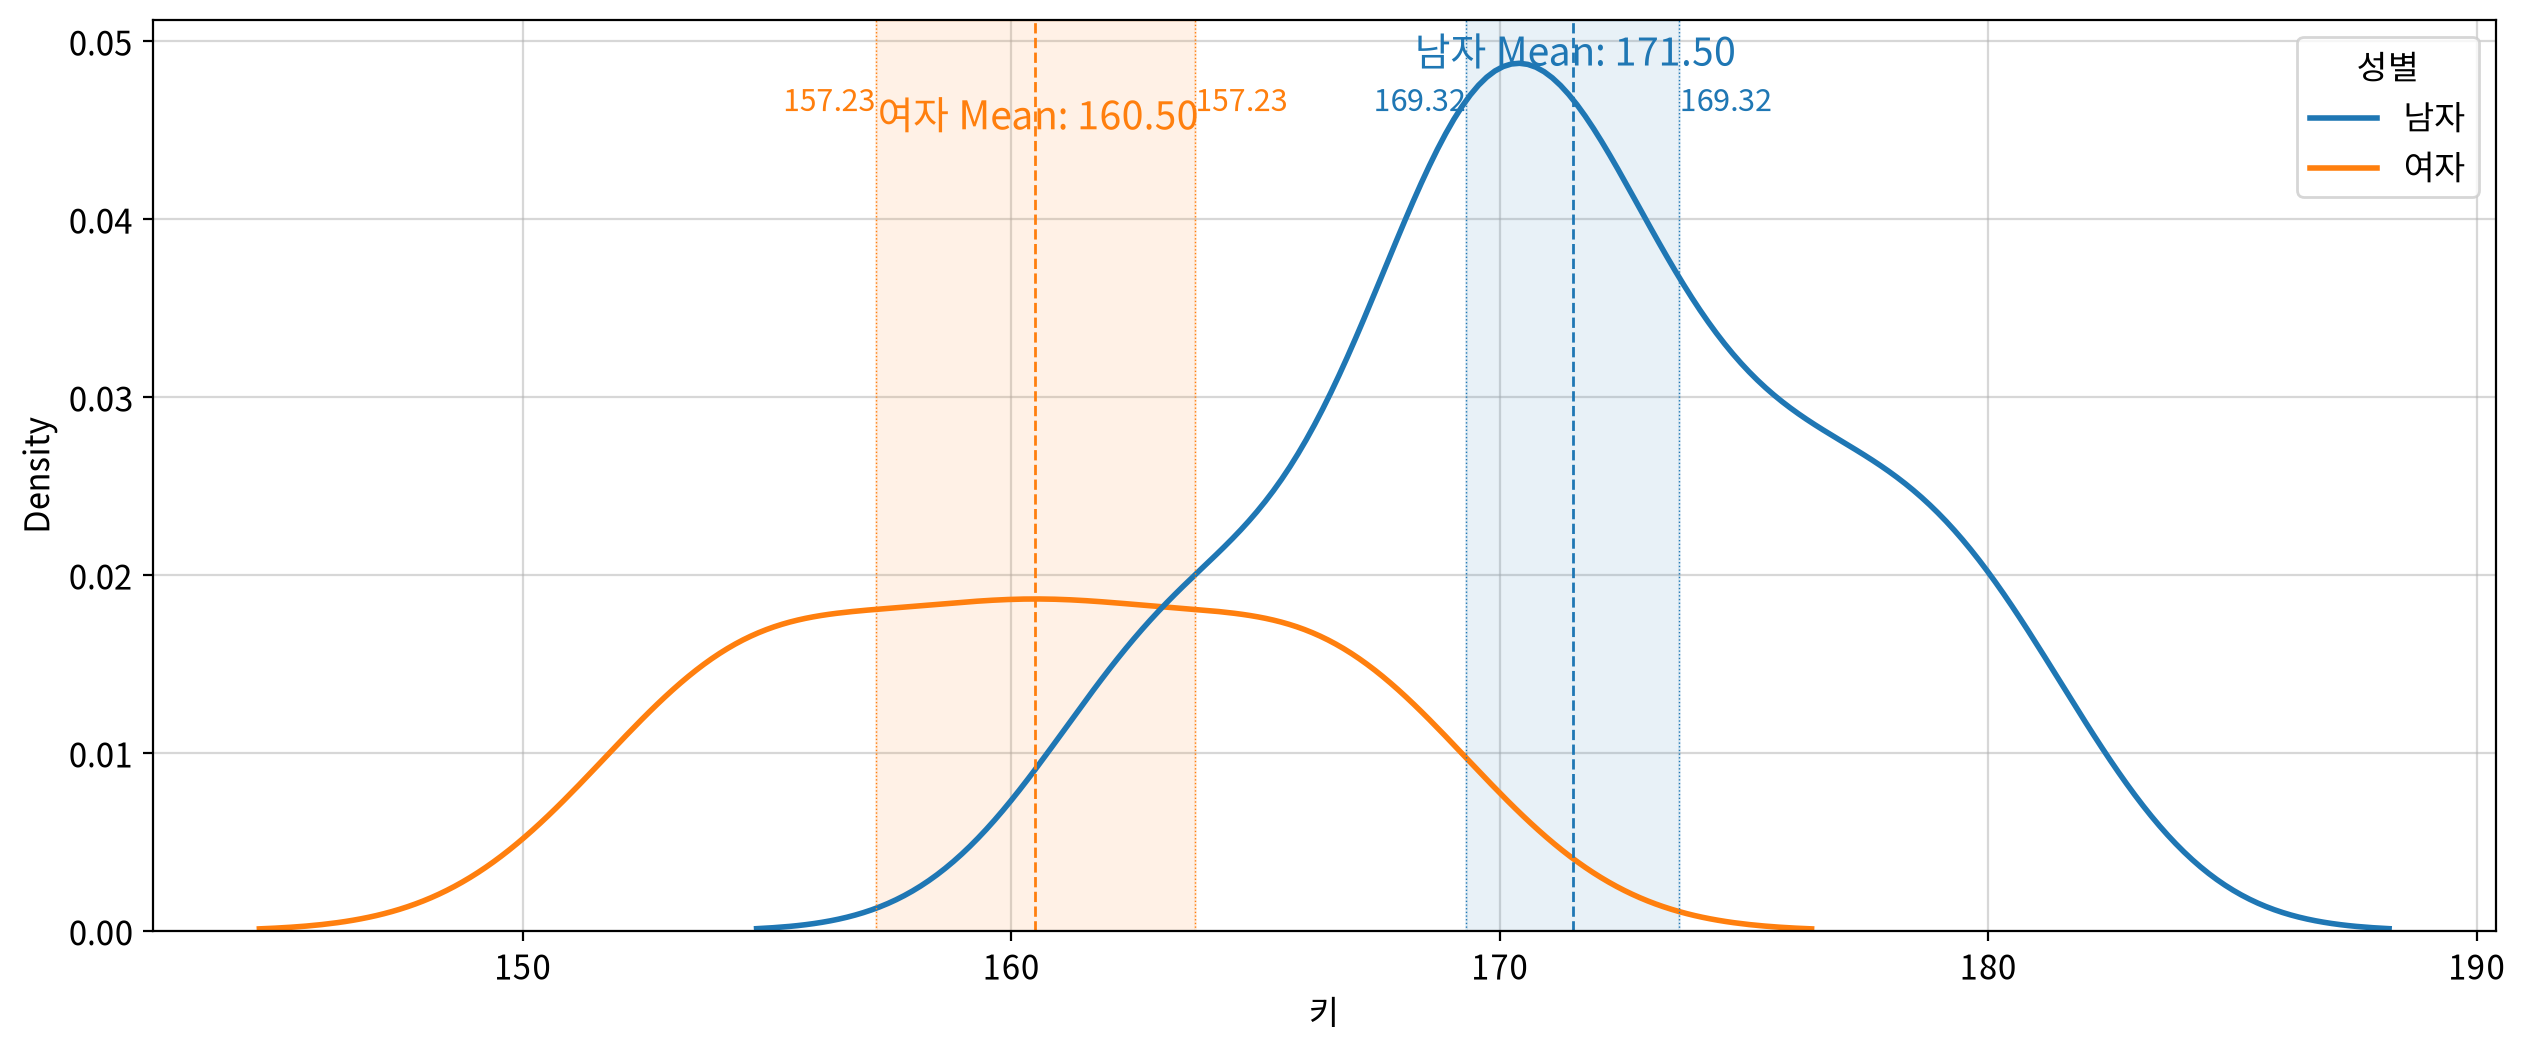

In [74]:
my_plot.kdeplot(origin, '키', hue='성별', meanline=True, clevel=0.95)

## #01. 연습문제 - 평균 광고비, 매출액 보고 

In [5]:
import pandas as pd

In [6]:
from jussam import load_data
from helpers import *
from pandas import melt, DataFrame

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


In [7]:
origin = load_data('ad_sales')
origin

📚 어느 회사의 월별 광고액과 매출액을 조사한 가상의 데이터


,월,광고비(백만원),매출액(억원)
0,1월,2,100
1,2월,142,1690
2,3월,122,298
3,4월,130,390
4,5월,185,590
5,6월,121,200
6,7월,101,190
7,8월,199,460
8,9월,221,660
9,10월,139,350


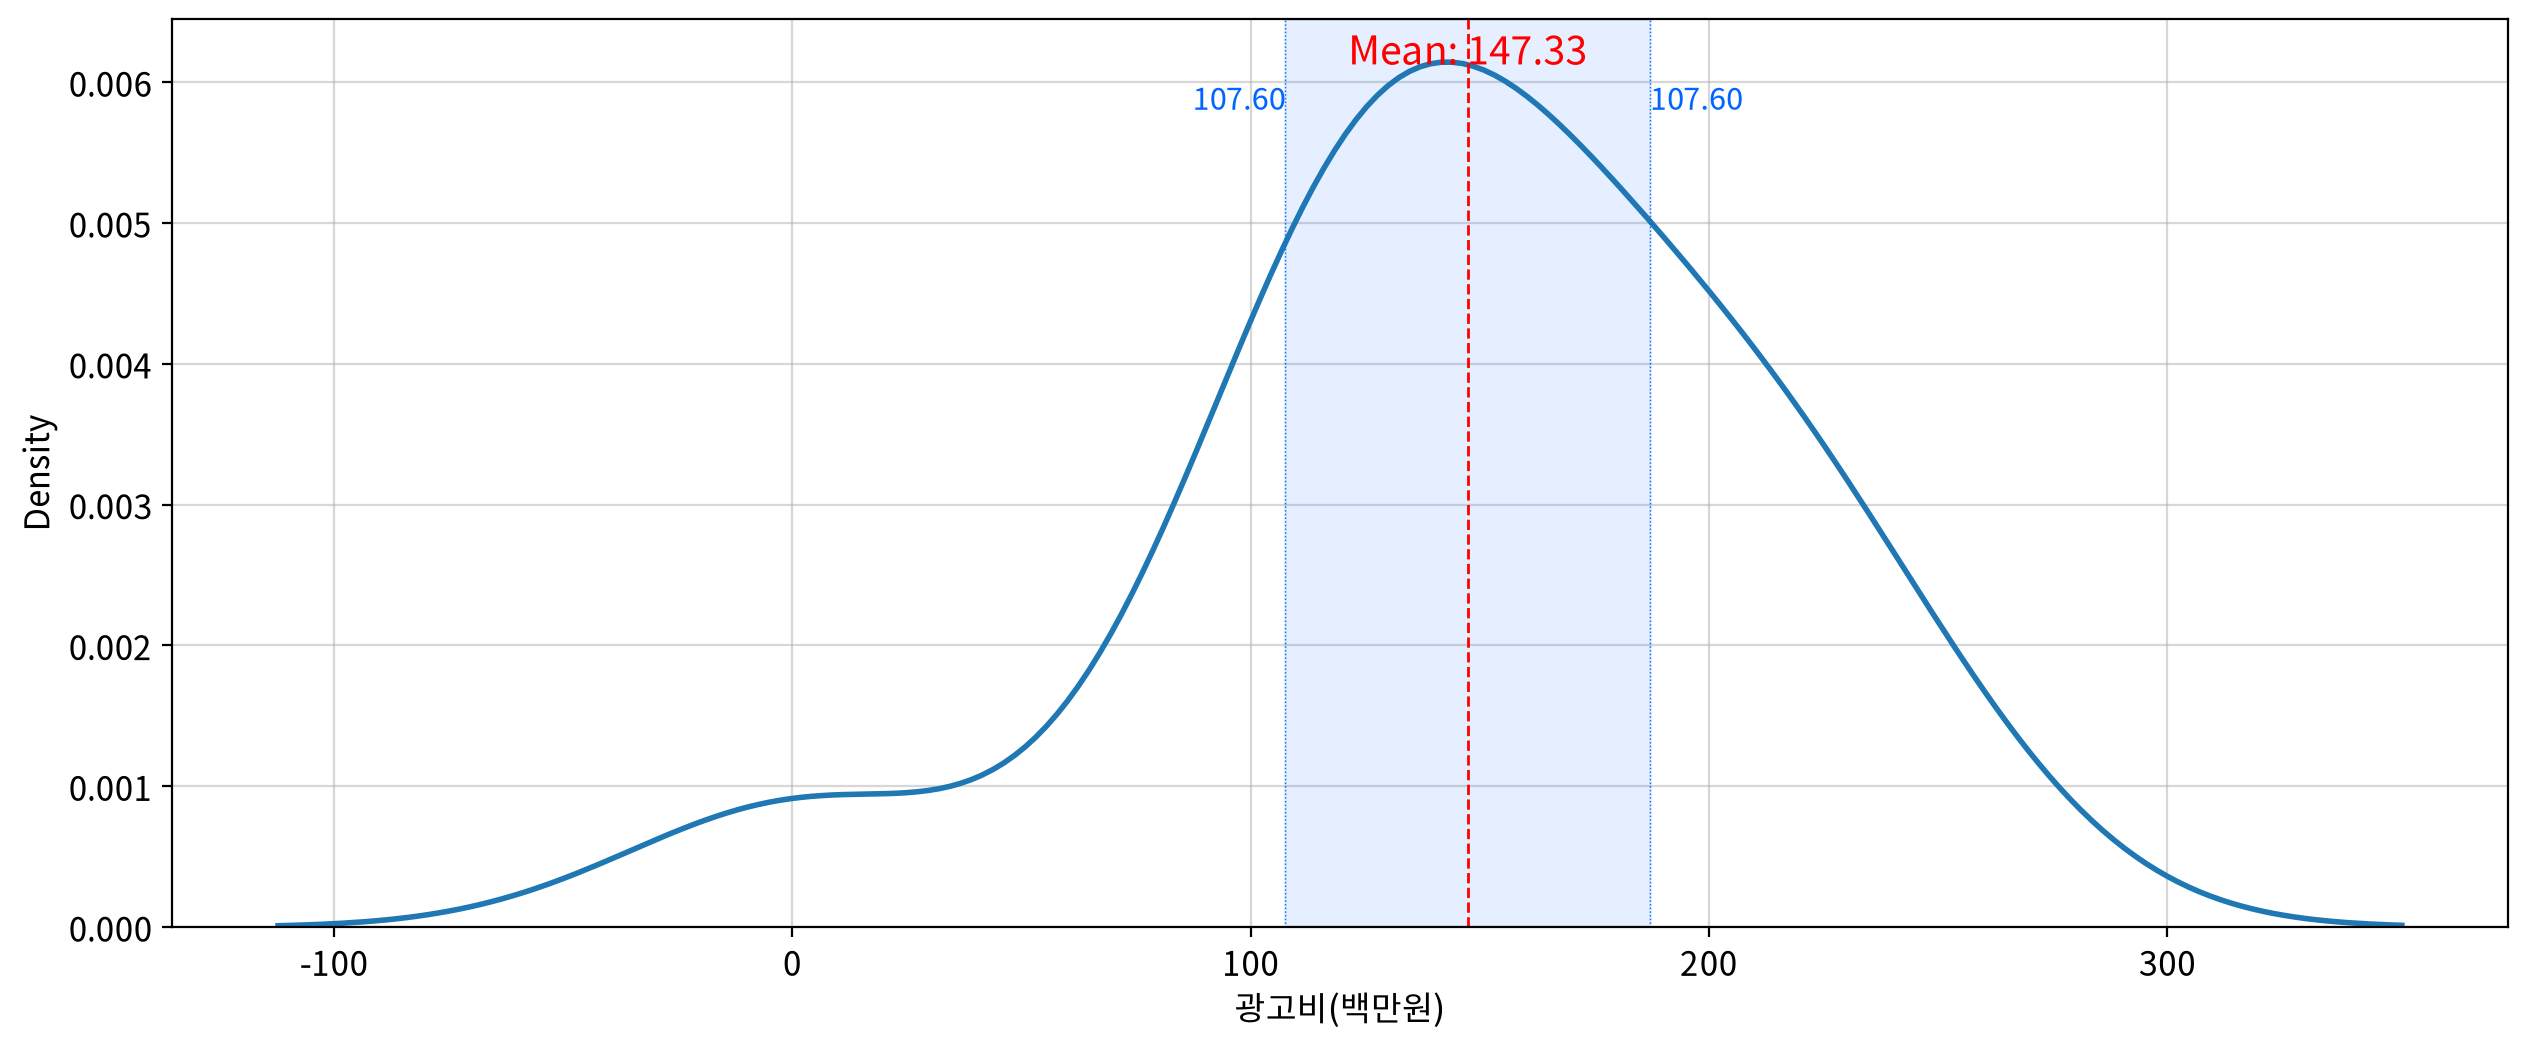

In [8]:
my_plot.kdeplot(origin, '광고비(백만원)', meanline=True, clevel=0.95)

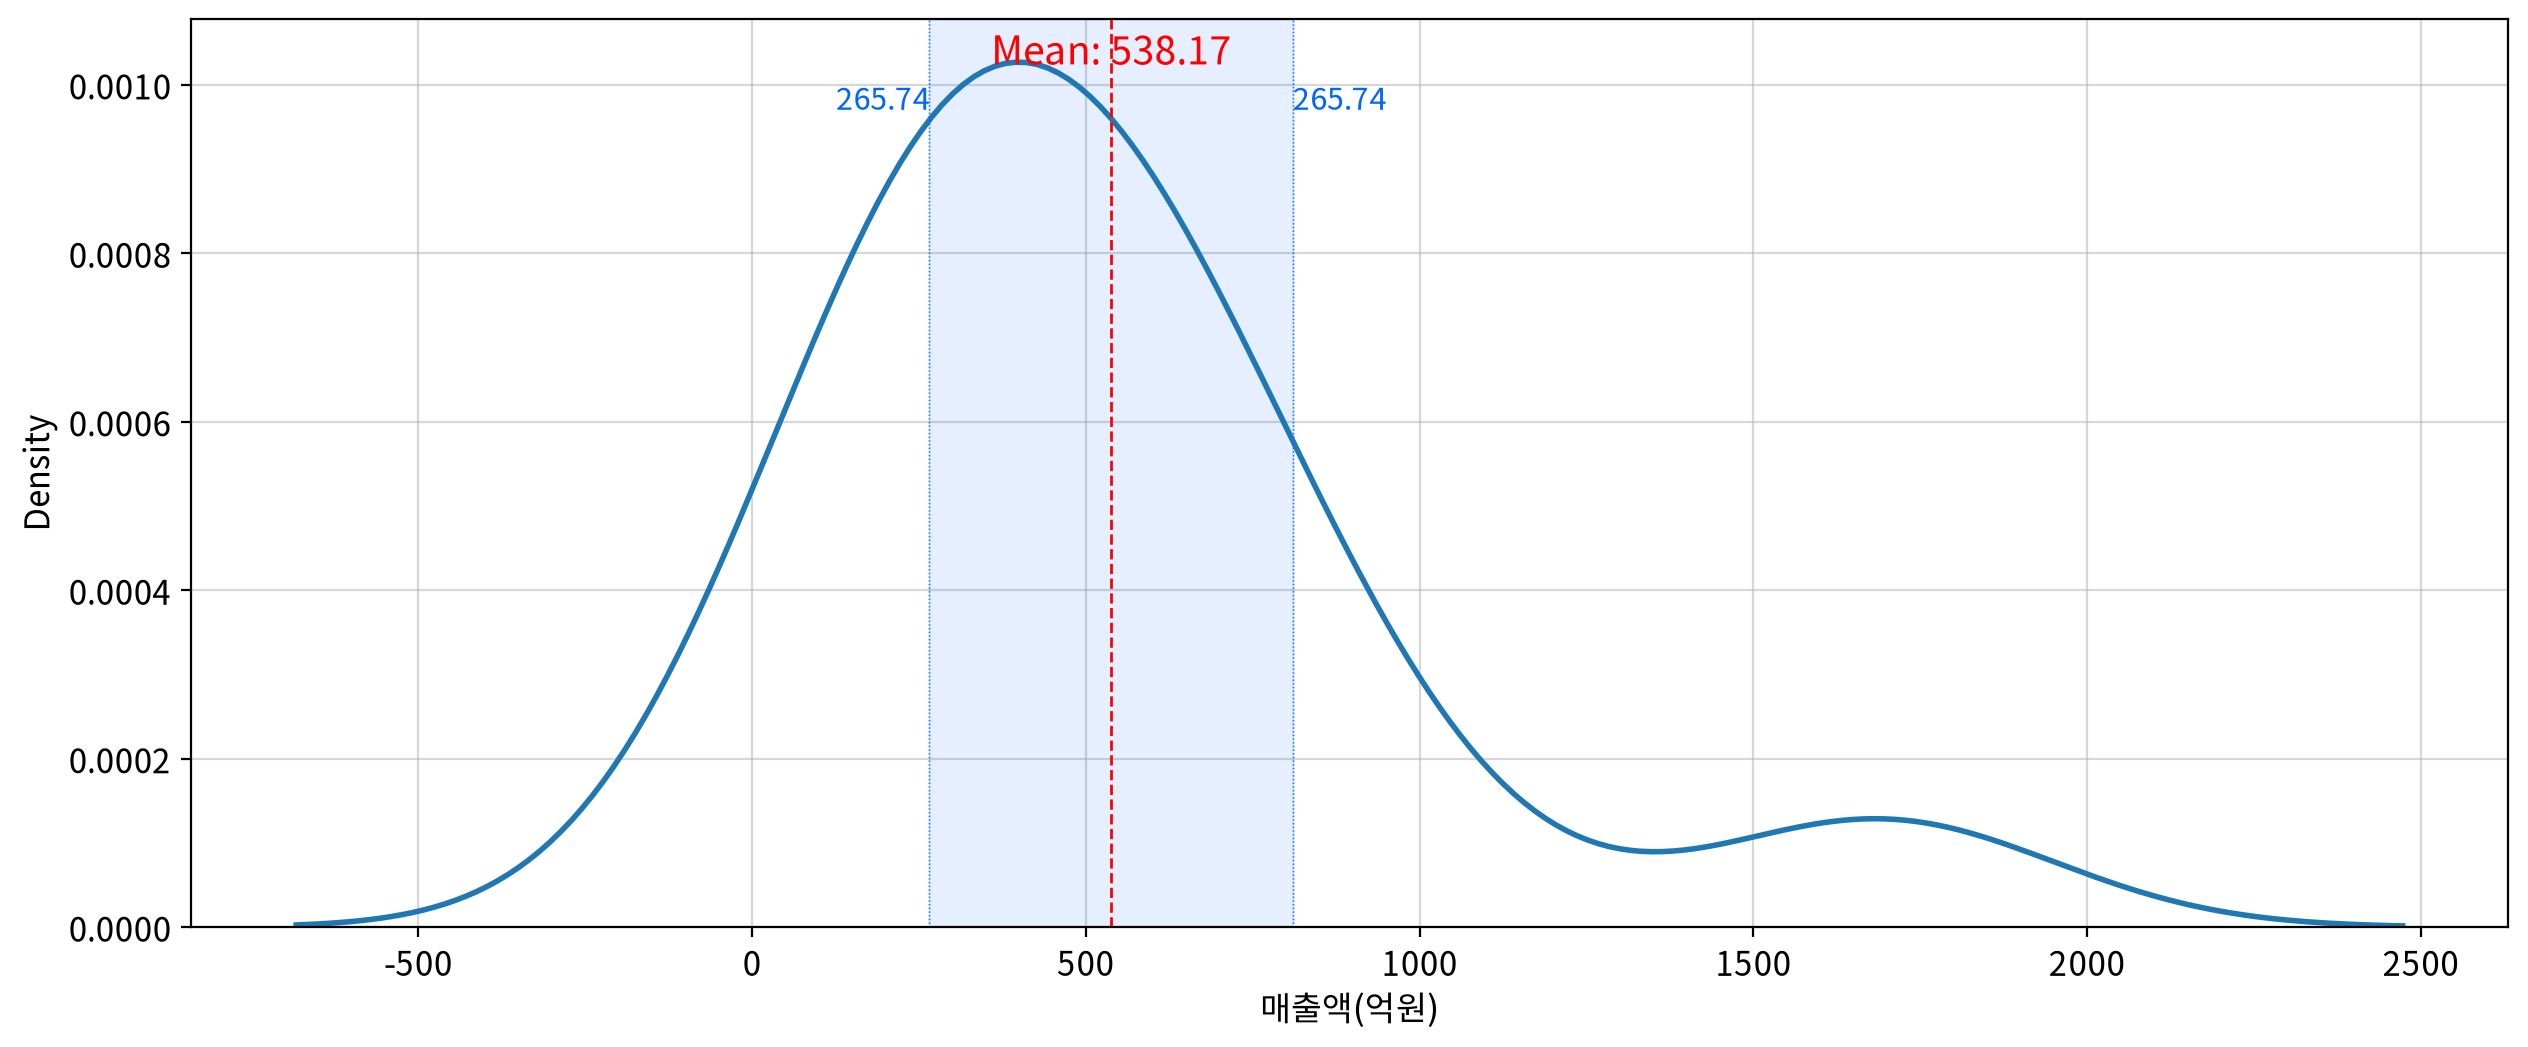

In [9]:
my_plot.kdeplot(origin, '매출액(억원)', meanline=True, clevel=0.95)

In [10]:
df =pd.melt(origin, id_vars='월', var_name='구분', value_name='금액')
df.head()

,월,구분,금액
0,1월,광고비(백만원),2
1,2월,광고비(백만원),142
2,3월,광고비(백만원),122
3,4월,광고비(백만원),130
4,5월,광고비(백만원),185


In [11]:
df= pd.melt(origin, id_vars='월',
           value_vars=['광고비(백만원)', '매출액(억원)'])
           #var_name='구분', value_name='매출')
df

,월,variable,value
0,1월,광고비(백만원),2
1,2월,광고비(백만원),142
2,3월,광고비(백만원),122
3,4월,광고비(백만원),130
4,5월,광고비(백만원),185
5,6월,광고비(백만원),121
6,7월,광고비(백만원),101
7,8월,광고비(백만원),199
8,9월,광고비(백만원),221
9,10월,광고비(백만원),139


In [14]:
# 'variable'은 '광고비/매출액' 같은 범주(카테고리) 컬럼이라 
# kde의 x축(연속형 수치)으로 쓸 수 없어요. 
# 실제 그려야 할 건 'value'고, 
# '광고비'와 '매출액'을 색으로 구분하려면 hue='variable'이어야 해요.

# my_plot.kdeplot(df, 'variable', hue='월', meanline=True, clevel=0.95)

In [ ]:
df =melt(origin, id_vars='월', var_name='구분', value_name='금액')
df.head()

,월,구분,금액
0,1월,광고비(백만원),2
1,2월,광고비(백만원),142
2,3월,광고비(백만원),122
3,4월,광고비(백만원),130
4,5월,광고비(백만원),185


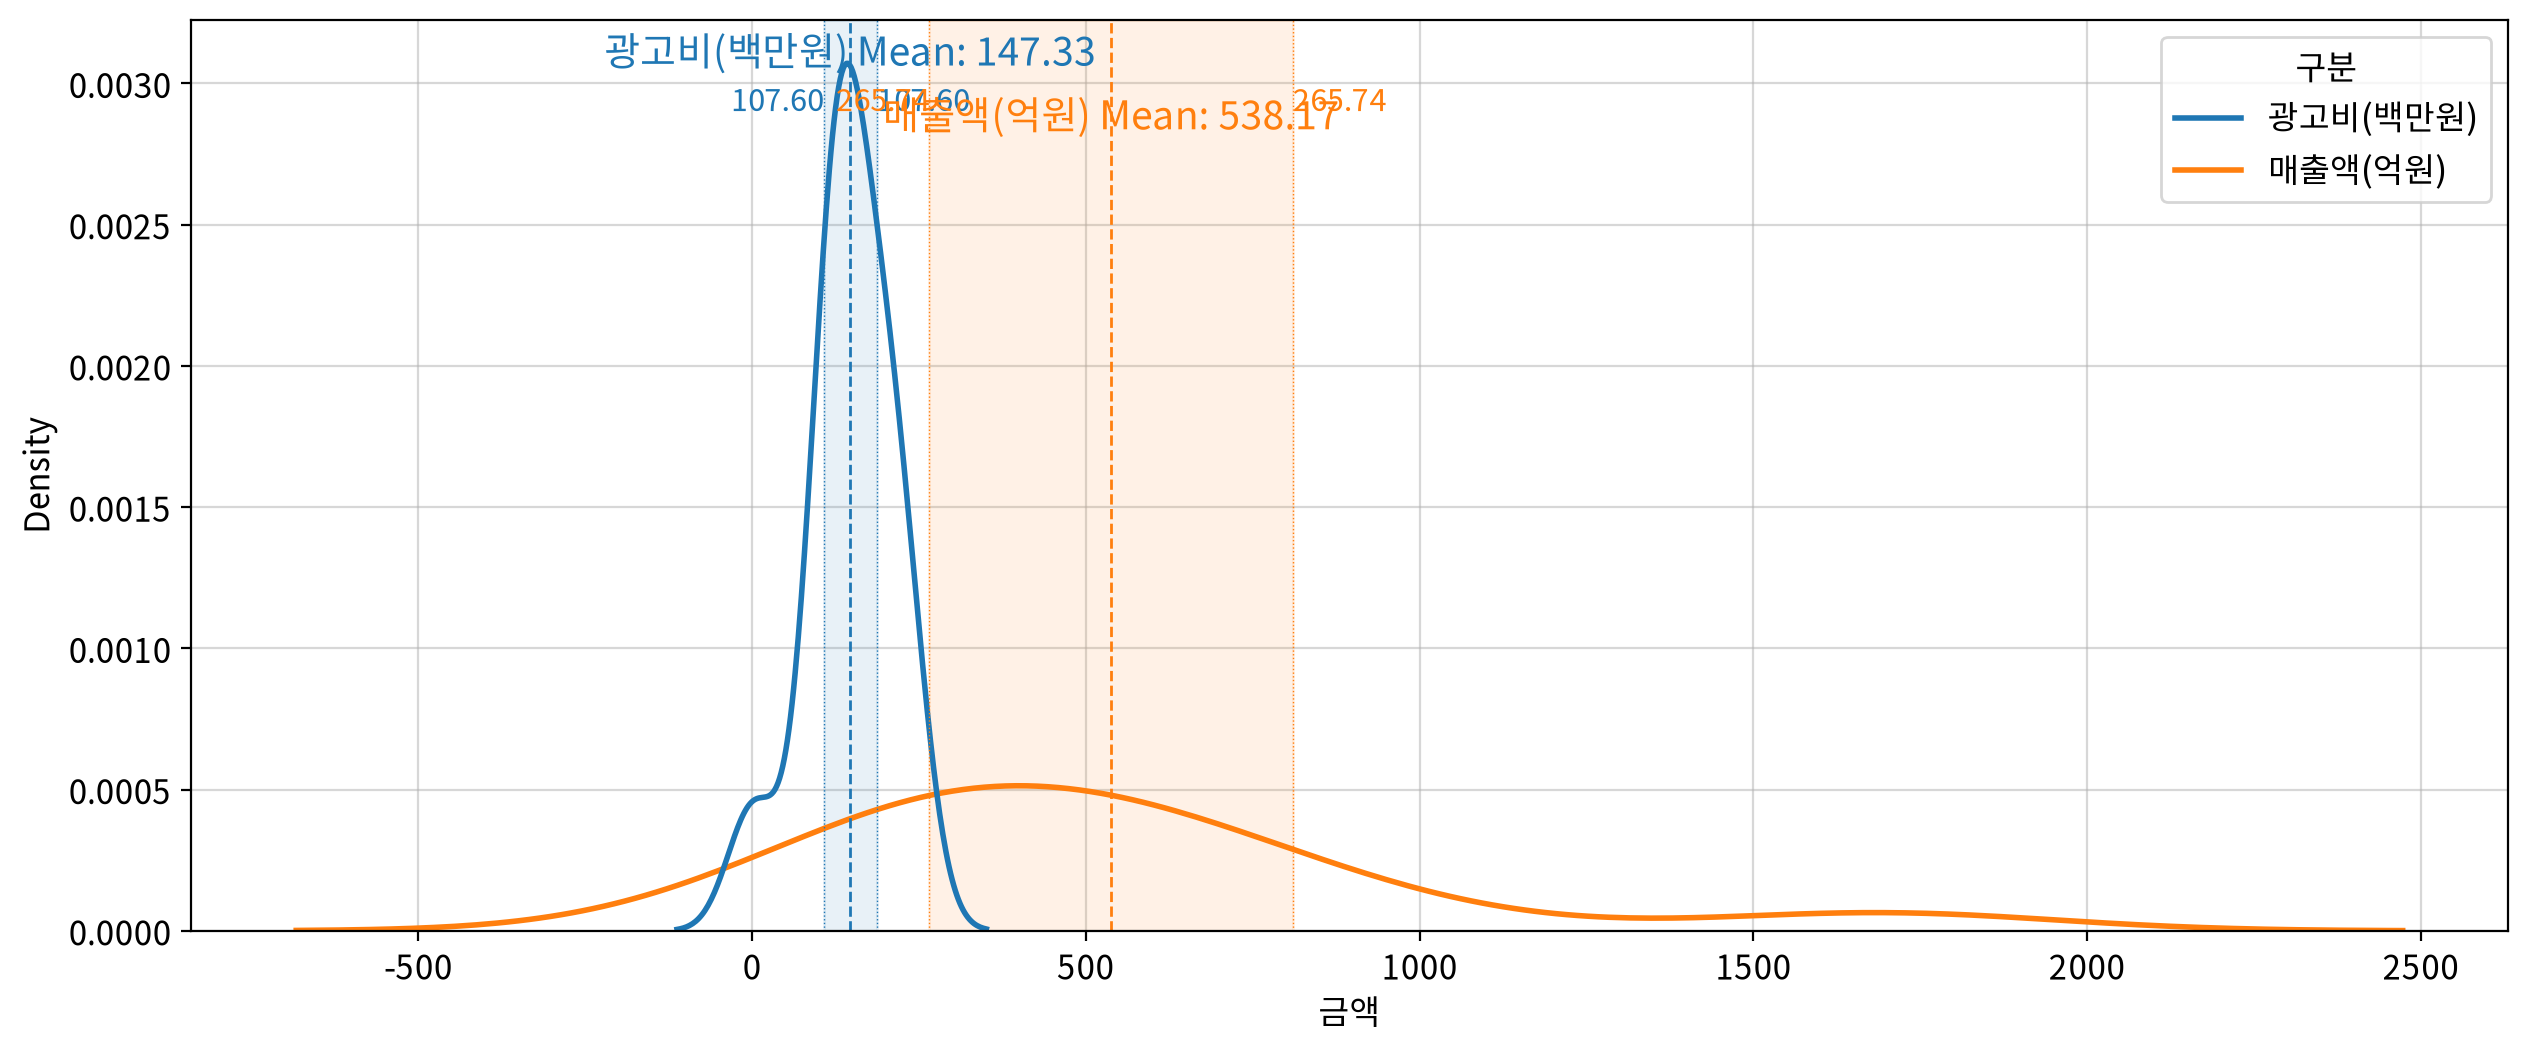

In [ ]:
my_plot.kdeplot(df, '금액', hue='구분', meanline=True, clevel=0.95)